# Motivation und Zielsetzung
Ziel der Bearbeitung war es ein hauseigenes Beet bedarfsgerecht und automatisiert mit Wasser zu versorgen. Um ein Überwässern oder Austrocknen zu vermeiden, wird mittels Sensorik die Bodenfeuchte gemessen. Es werden Umwelteinflüsse sowie alle Sensorwerte aufgezeichnet und gespeichert, um daraus möglicherweise durch ein Machine Learning Gießzeitpunkte oder Austrocknung vorherzusagen.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns

# Dateipfade festlegen
VENV_DIR = Path.cwd()
DATA_DIR = VENV_DIR / 'Daten'

# 1. Versuchsaufbau 

Um eine automatisierte Bewässerung zu realisieren, muss Wasser zum Gießen aus einem Reservoir in das Beet befördert werden. Der schematische Aufbau ist in Abbildung 1 zu sehen. Dazu wird eine 12 V DC Pumpe verwendet, die mittels eines 3,3V Relais angesteuert wird und 12 l/min fördern kann. Die Pumpe wird unterhalb des Wasserbehälters positioniert, damit die Saugleitung der Pumpe bei jedem Füllstand vollständig mit Wasser gefüllt ist. Versuche haben gezeigt, dass die Pumpe nicht in der Lage ist bei einer größeren Luftblase in der Saugleitung noch Wasser zu fördern. Wenn der Sollwert unterschritten wird und die Pumpe laufen soll, muss sichergestellt sein, dass die komplette Leitung mit Wasser gefüllt ist. Ansonsten würde sich die Wassersäule immer mit dem Füllstand des Behälter ausgleichen und der Förderweg variieren. Der idealste Fall wäre wenn die Wassersäule stehen bleiben würde und die Druckleitung immer nahezu komplett mit Wasser gefüllt wäre. Dazu wird ein Rückschlagventil in den Fließweg eingebaut, das ein Abfallen der Wassersäule verhindert.  

<div style="display: flex; justify-content: space-around; align-items: center;">
    <figure style="text-align: center;">
    <img src='Bilder/Aufbau_Schema.png' alt='Schema' width='200%'> 
    <figcaption><i>Abb. 1: Schematischer Aufbau</i></figcaption>
    </figure>
    <figure style="text-align: center;">
    <img src='Bilder/Pump.jpeg' alt='Pumpe' width='35%'> 
    <figcaption><i>Abb. 2: 12V DC Pumpe</i></figcaption>
    </figure>
</div>

Für den Wasserbehälter wird ein durchsichtiger Kunststoffkanister verwendet, sodass man den Füllstand einsehen kann und von oben nachfüllen kann. Der Behälter muss oben geöffnet bleiben, damit bei Betrieb der Pumpe kein Unterdruck entsteht.  
Für die Verteilung des Wassers im Beetkasten wird ein Schlauch mit 13 mm Innendurchmesser verwendet. In diesen werden im Bereich des Beetes in längsrichtung Löcher eingebracht aus denen das Wasser austreten kann.

## 1.1 Mikrocontroller
Das Herz des Aufbaus bildet der ESP32-Mikrocontroller. Auf diesen werden die Programme geflasht und können ausgeführt werden. Hier werden die Sensoren und Aktoren angeschlossen und Messwerte können ausgelesen, umgerechnet und gespeichert werden. 

<div align=center>
    <figure>
    <img src='Bilder/Microcontroller.jpeg' alt='ESP32' width='25%'> 
    <figcaption><i>Abb. 2: Mikrocontroller ESP32 </i></figcaption>
    </figure>
</div>


### 1.1.1 Micropython
Zur Programmierung wurde [Micropython](https://micropython.org) verwendet. Dabei handelt es sich um eine an Python angelehnte Programmiersprache, welche größtenteils mit dem Standardpython kompatibel ist. So ist ein schneller Austausch von Programmen von Computer zu Microcontroller möglich.  
Um Micropython auf dem ESP32 zu verwenden muss die passende Firmware auf den Microcontroller *geflasht* werden. Diese steht für eine Vielzahl von Microcontrollern auf der Micropython Webseite zum Download bereit. Der ESP32 kann dann mittels USB-C Kabels mit dem Rechner verbunden werden und über das Terminal bzw. den Windows Command Prompt (*cmd*) kann die Firmware geflasht werden. Eine detaillierte Anleitung findet man [hier](https://micropython.org/download/ESP32_GENERIC/).  
Danach kann mit einer geeigneten IDE Programmcode auf dem ESP32 ausgeführt werden. Wir haben hier größtenteils mit der Thonny IDE und Visual Studio Code gearbeitet.

## 1.2 Bodenfeuchtesensor
Zur Messung der Bodenfeuchte wird ein kapazitiver Feuchtigkeitssensor eingesetzt. Dieser wird senkrecht in den Boden eingebracht. Das Wasser fungiert bei einem kapazitiven Sensor als Dielektrikum zwischen den Platten des Kondensator und besitzt eine deutlich größere Dielektrizitätszahl $\varepsilon_r$ als trockene Erde. Je mehr Wasser zwischen zwischen den Platten vorhanden ist, desto höher ist die Kapazität des Kondensators. Diese kann letztendlich gemessen werden. Die Bodenfeuchte soll später als Regelgröße für die Pumpe dienen.

<div align=center>
    <figure>
    <img src='Bilder/Feuchtesensor.jpeg' alt='Bodenfeuchtesensor' style="transform: rotate(180deg);" width=25%>
    <figcaption><i>Abb. 3: Kapazitiver Bodenfeuchtesensor </i></figcaption>
    </figure>
</div>

### 1.2.1 Kalibrierung
Damit der Sensor genaue Werte liefert, wird dieser in der verwendeten Erde kalibriert. Anschließend wird daraus eine Funktion abgeleitet, welche in den Programmcode hinterlegt wird. Die Werte wurden mithilfe einer Erdprobe, zwei Bechern und einer Küchenwaage durchgeführt. Die Blumenerde wurde vorher im Backofen kurz durchgetrocknet. Danach wurde der Sensorwert bei vollkommen trockener Erde ermittelt. Dann werden sukzessive 20 ml Wasser in die Erde gegossen und jedes mal die Werte aufgenommen. Es wurden bei jeder Stufe jeweils zehn Werte aufgenommen und gemittelt. Mittels ```scipy.optimize``` werden aus den Datenpunkten die Parameter einer Polynomfunktion bestimmt. Diese Funktion konnte dann im Code auf den ESP32 eingesetzt werden.  

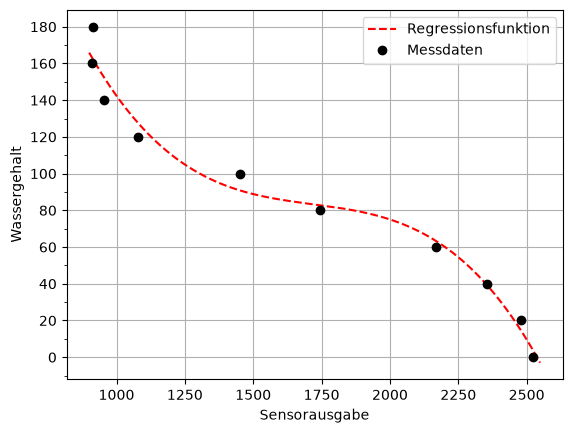

In [2]:
from scipy.optimize import curve_fit

sensor = pd.read_excel(DATA_DIR / 'Kalibrierung_Feuchtesensor.xlsx', sheet_name='v1.2_csv', index_col=0)
mittel = sensor.groupby(sensor.index)['Messwerte'].mean()

def func_sensor(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d

rohwert = mittel.to_numpy()
moisture = mittel.index.to_numpy()
popt, _ = curve_fit(func_sensor, rohwert, moisture)

y = [func_sensor(i, *popt) for i in range(900, 2550)]

fig, ax = plt.subplots()

ax.plot(range(900, 2550), y, label='Regressionsfunktion', ls='--', c='r')
ax.plot(rohwert, moisture, label='Messdaten', ls='', marker='o', c='k')
ax.grid(True)
ax.yaxis.set_minor_locator(plt.MultipleLocator(10))
ax.yaxis.set_major_locator(plt.MultipleLocator(20))
ax.set_xlabel('Sensorausgabe')
ax.set_ylabel('Wassergehalt')
ax.legend()
plt.show()

## 1.3 Umgebungsdaten
Zur Datensammlung sollen auch die Umgebungstemperatur, -feuchte und -Druck gemessen werden. Hierzu wird ein Bosch BME280 eingesetzt. Dieser Sensor kann alle drei Werte messen. Die Messgenauigkeiten finden sich in Tabelle 1. Der Sensor kommuniziert mit dem ESP32 über eine $\mathrm{I^2C}$ Verbindung. Die Initialisierung der Sonsoren erfolgt dann über ein Skript in Micropython, welches auf den ESP32 geflasht wird.

<div align=center>
    <figure>
    <img src='Bilder/BME280.jpeg' alt='BME280' width='25%'> 
    <figcaption><i>Abb. 4: Platine mit BME280 Sensor</i></figcaption>
    </figure>
</div>

<div align="center">
    <b>Tab. 1: Messspezifikationen und Genauigkeiten des BME280 Sensors</b>
</div>

| Sensor-Parameter | Messbereich | Absolute Genauigkeit (Tolerance) | Relative Genauigkeit (Präzision) |
| :--- | :--- | :--- | :--- |
| **Luftdruck** | 300 ... 1100 hPa | $\pm$ 1,0 hPa (0 bis +65 °C) | $\pm$ 0,12 hPa |
| **Temperatur** | -40 ... +85 °C | $\pm$ 0,5 °C (bei 25 °C) | - |
| **Luftfeuchtigkeit** | 0 ... 100 % r.H. | $\pm$ 3 % relative Feuchte | -|

## 1.4 Datenspeicherung
Wir speichern die Daten direkt auf dem ESP32. Beim Starten der Messung wird auf dem ESP32 ein Accesspoint erstellt. Somit ist es möglich sich über WLAN mit diesem zu verbinden. Um die Daten abzurufen ohne jedesmal die Messung unterbrechen und den ESP32 mit dem Computer verbinden zu müssen, werden die Daten auf einen Webserver hochgeladen und angezeigt. Mir einem Computer oder Smartphone können die Daten eingesehen werden und sich die bis dahin gefüllte CSV-Datei heruntergeladen werden.

<div align=center>
    <figure>
    <img src='Bilder/Webserver.png' alt='Webserver' width=50%>
    <figcaption><i>Abb. 5: Datenanzeige auf dem Webserver </i></figcaption>
    </figure>
</div>

Die Daten werden temporär auf dem Arbeitsspeicher des ESP32 gespeichert. Um einen Datenverlust bei Stromausfall zu vermeiden, werden die Daten viermal am Tag vom Arbeitsspeicher auf den dauerhaften Datenträger des gespeichert.

Um die Messungen einem Zeitpunkt zuzuordnen wird beim Start der Messung die Zeit des Microcontrollers über das Internet synchronisiert und Zeitstempel im Format YYYY:mm:dd HH:MM:SS mitgeschrieben. Zurzeit ist geplant im Intervall von 15 Minuten Daten aufzunehmen.

# 2 Datenstruktur & -typen
Um die Messungen einem Zeitpunkt zuzuordnen wird beim Start der Messung die Zeit des Microcontrollers über das Internet synchronisiert und Zeitstempel im Format YYYY:mm:dd HH:MM:SS mitgeschrieben. Zurzeit ist geplant im Intervall von 15 Minuten Daten aufzunehmen.

In [3]:
# Datensatz einladen
data_raw = pd.read_csv(DATA_DIR / 'sensor_data.csv', sep=',', encoding='utf-8')
data_raw.info()
data_raw.head()

<class 'pandas.DataFrame'>
RangeIndex: 2547 entries, 0 to 2546
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      2547 non-null   int64  
 1   datetime       2547 non-null   str    
 2   humidity       2386 non-null   float64
 3   pressure       2386 non-null   float64
 4   pump_time      2386 non-null   float64
 5   soil_moisture  2386 non-null   float64
 6   temperature    2386 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 139.4 KB


,timestamp,datetime,humidity,pressure,pump_time,soil_moisture,temperature
0,836567568,2026-07-05 13:52:48,70.64,1013.73,0.0,101.92,21.02
1,836567568,2026-07-05 13:52:48,NaN,NaN,NaN,NaN,NaN
2,836567604,2026-07-05 13:53:24,71.50,1013.74,0.0,102.10,20.79
3,836568504,2026-07-05 14:08:24,71.59,1013.66,0.0,100.20,20.77
4,836569404,2026-07-05 14:23:24,71.92,1013.55,0.0,96.03,21.92


Der Datensatz besteht aus sieben Spalten. Aufgenommen wurden hier folgende Spalten:
- timestamp
- datetime
- humidtiy (BME)
- pressure (BME)
- pump_time
- soil_moisture
- temperature (BME)

Alle Spalten mit Zahlenwerten sind 64-bit Floats, bis auf ```timestamp``` mit 64-bit Integern. Die Spalte ```datetime``` liegt als Strings vor. Diese sollte noch in ein datetime-Format konvertiert werden und als Index festgelegt werden, damit falls nötig Slicing angewendet werden kann.
```timestamp``` und ```datetime``` sind fortlaufende Spalten und enthalten keine NaN-Werte.

In [4]:
data_raw.isna().sum()

timestamp          0
datetime           0
humidity         161
pressure         161
pump_time        161
soil_moisture    161
temperature      161
dtype: int64

Die übrigen Spalten enthalten 161 NaN-Werte.

# Explorative Datenanalyse


In [5]:
# Datetimeindex festlegen
format = '%Y-%m-%d %H:%M:%S'
data_raw['datetime'] = pd.to_datetime(data_raw['datetime'], format=format)
data_raw = data_raw.set_index('datetime')

Wurde der Datensatz über den Webserver heruntergeladen, wurden dem Datensatz Datenlücken hinzugefügt bzw. einige Zeilen wurden mit leeren überschrieben. Für dieses Problem konnte vorerst keine Lösung gefunden werden. Deshalb wurde der Datensatz nur noch über direkte USB-Verbindung mit dem ESP32 heruntergeladen. Allerdings befinden sich nun im Datensatz einige Zeitstempel doppelt. Diese müssen gefilter und entfernt werden, da dem Dataframe sonst keine Frequenz hinzugefügt werden kann.

Da es Probleme bei der Datenerfassung gab, existiert zwischen dem 09.07. und 03.08. eine große Lücke. Diese wird bei ```.asfreq``` vorwärtsaufgefüllt.

In [6]:
delete_mask = (
    (data_raw.index.duplicated(keep=False)) &
    (data_raw.isna().any(axis=1))
)
data = data_raw[~delete_mask]

# Probe wie viele NaN's übrig sind
data.isna().sum()

# Frequenz auf 15 min stellen
data = data.asfreq(freq='15min', method='ffill')

data.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 4819 entries, 2026-07-05 13:52:48 to 2026-08-24 18:22:48
Freq: 15min
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      4819 non-null   int64  
 1   humidity       4819 non-null   float64
 2   pressure       4819 non-null   float64
 3   pump_time      4819 non-null   float64
 4   soil_moisture  4819 non-null   float64
 5   temperature    4819 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 263.5 KB


Nachdem alle fehlerhaften Zeilen entfernt und die Frequenz festgelgt wurde, existieren keine NaN's mehr im Datensatz. Als nächstes können die Datenspalten visualisiert werden, um sich einen Überblick zu verschaffen. Die Spalte ```timestamp``` wird dabei erstmal vernachlässigt da diese sehr große werte enhält und die Skalierung stark verzerrt.

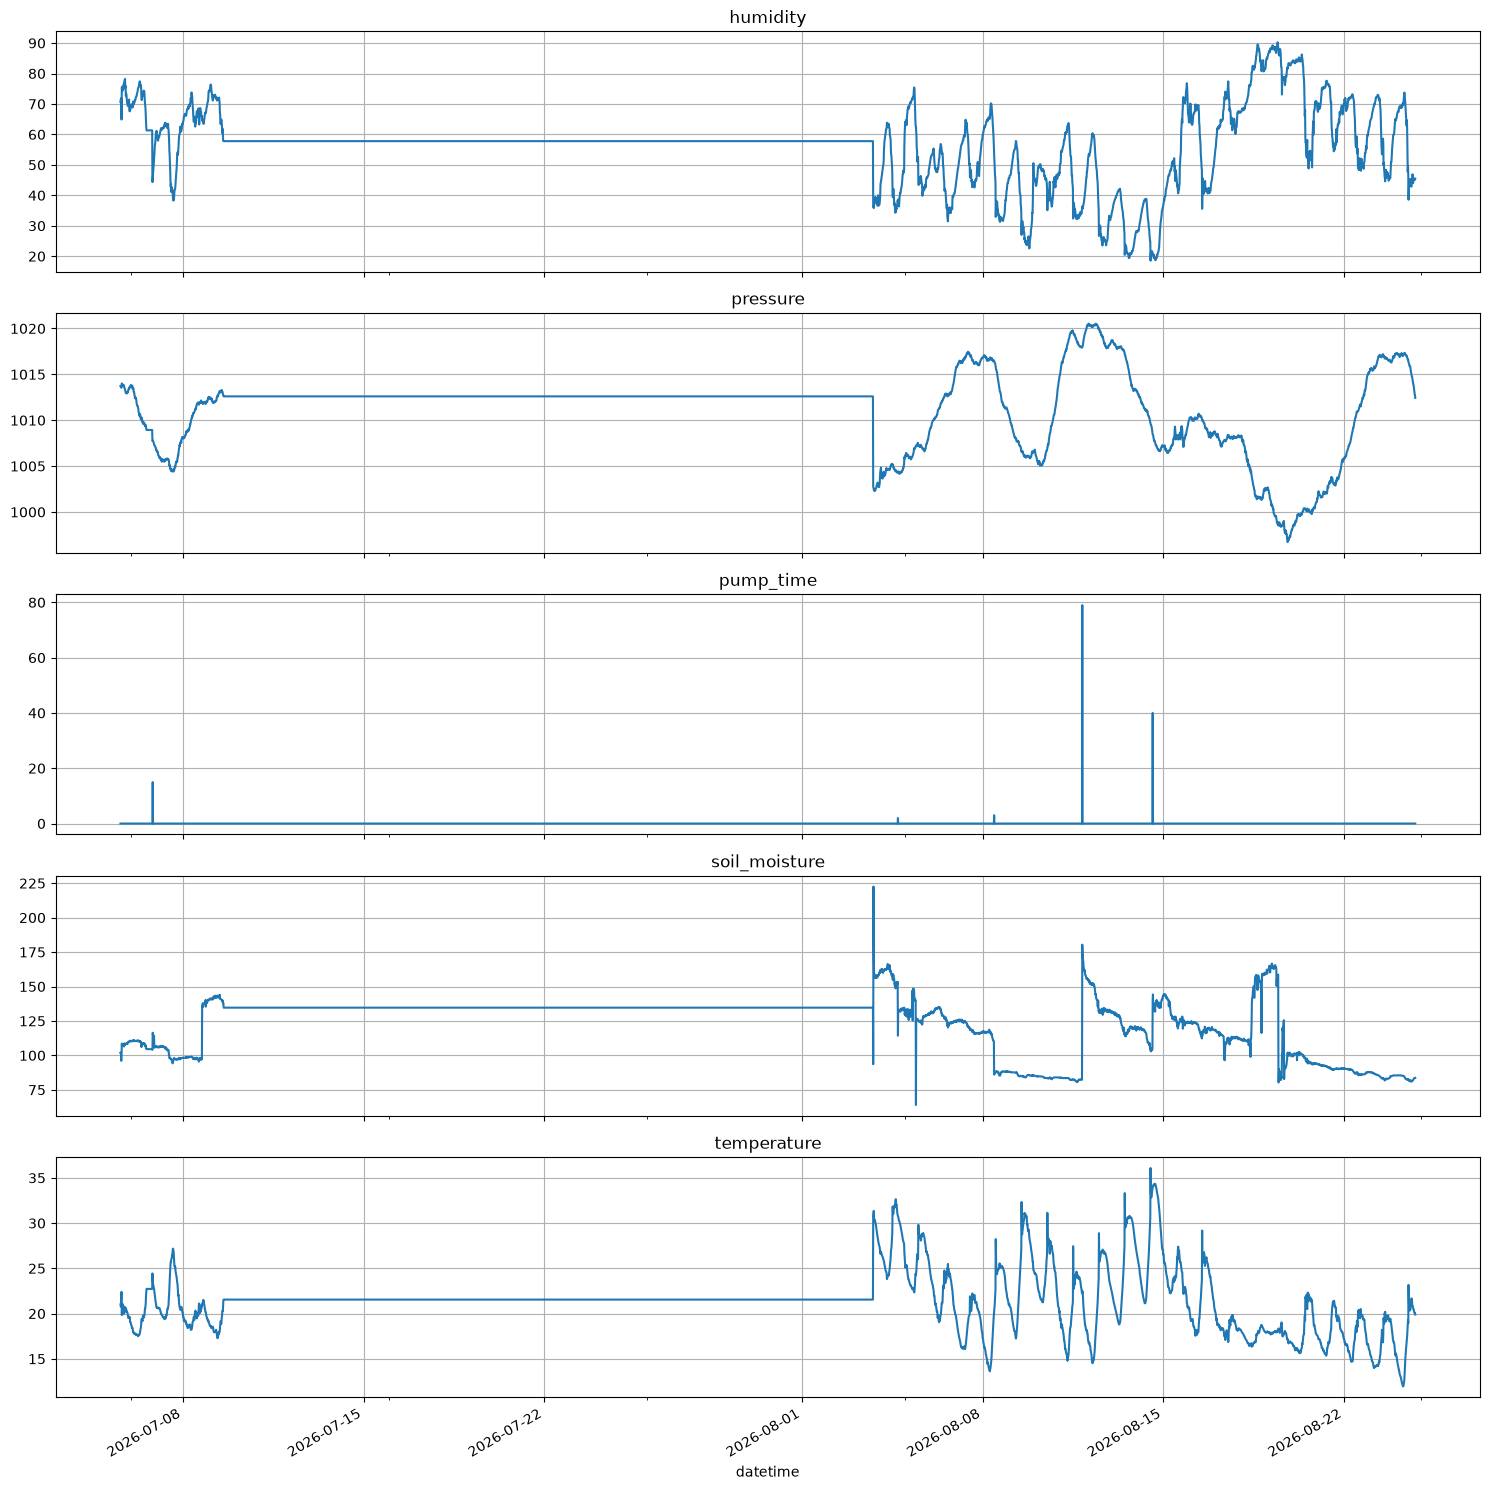

In [7]:
def plot_cols(df:pd.DataFrame, ignore= None):
    df = df.copy()
    if isinstance(ignore, str):
        ignore = [ignore]

    if ignore:
        df = df.drop(columns=ignore, errors=ignore)
        
    fig, ax = plt.subplots(len(df.columns), 1, figsize=(15, 3*len(df.columns)), sharex=True)
    for ax, col in zip(ax, df.columns):
        ax = df[col].plot(ax = ax)
        ax.set_title(col)
        ax.grid(True)

    fig.tight_layout()

plot_cols(data, ignore='timestamp')

Die Lücke wird hier deutlich über eine konstante Gerade in genannten Zeitraum. Zur besseren Sichtbarkeit wird die Betrachtung auf den rechten Bereich konzentriert und in einem neuen Dataframe ```data_aug``` gepeichert. Aus diesem werden dann alle Zeilen in denen sich der gleiche Timestamp befindet entfernt.

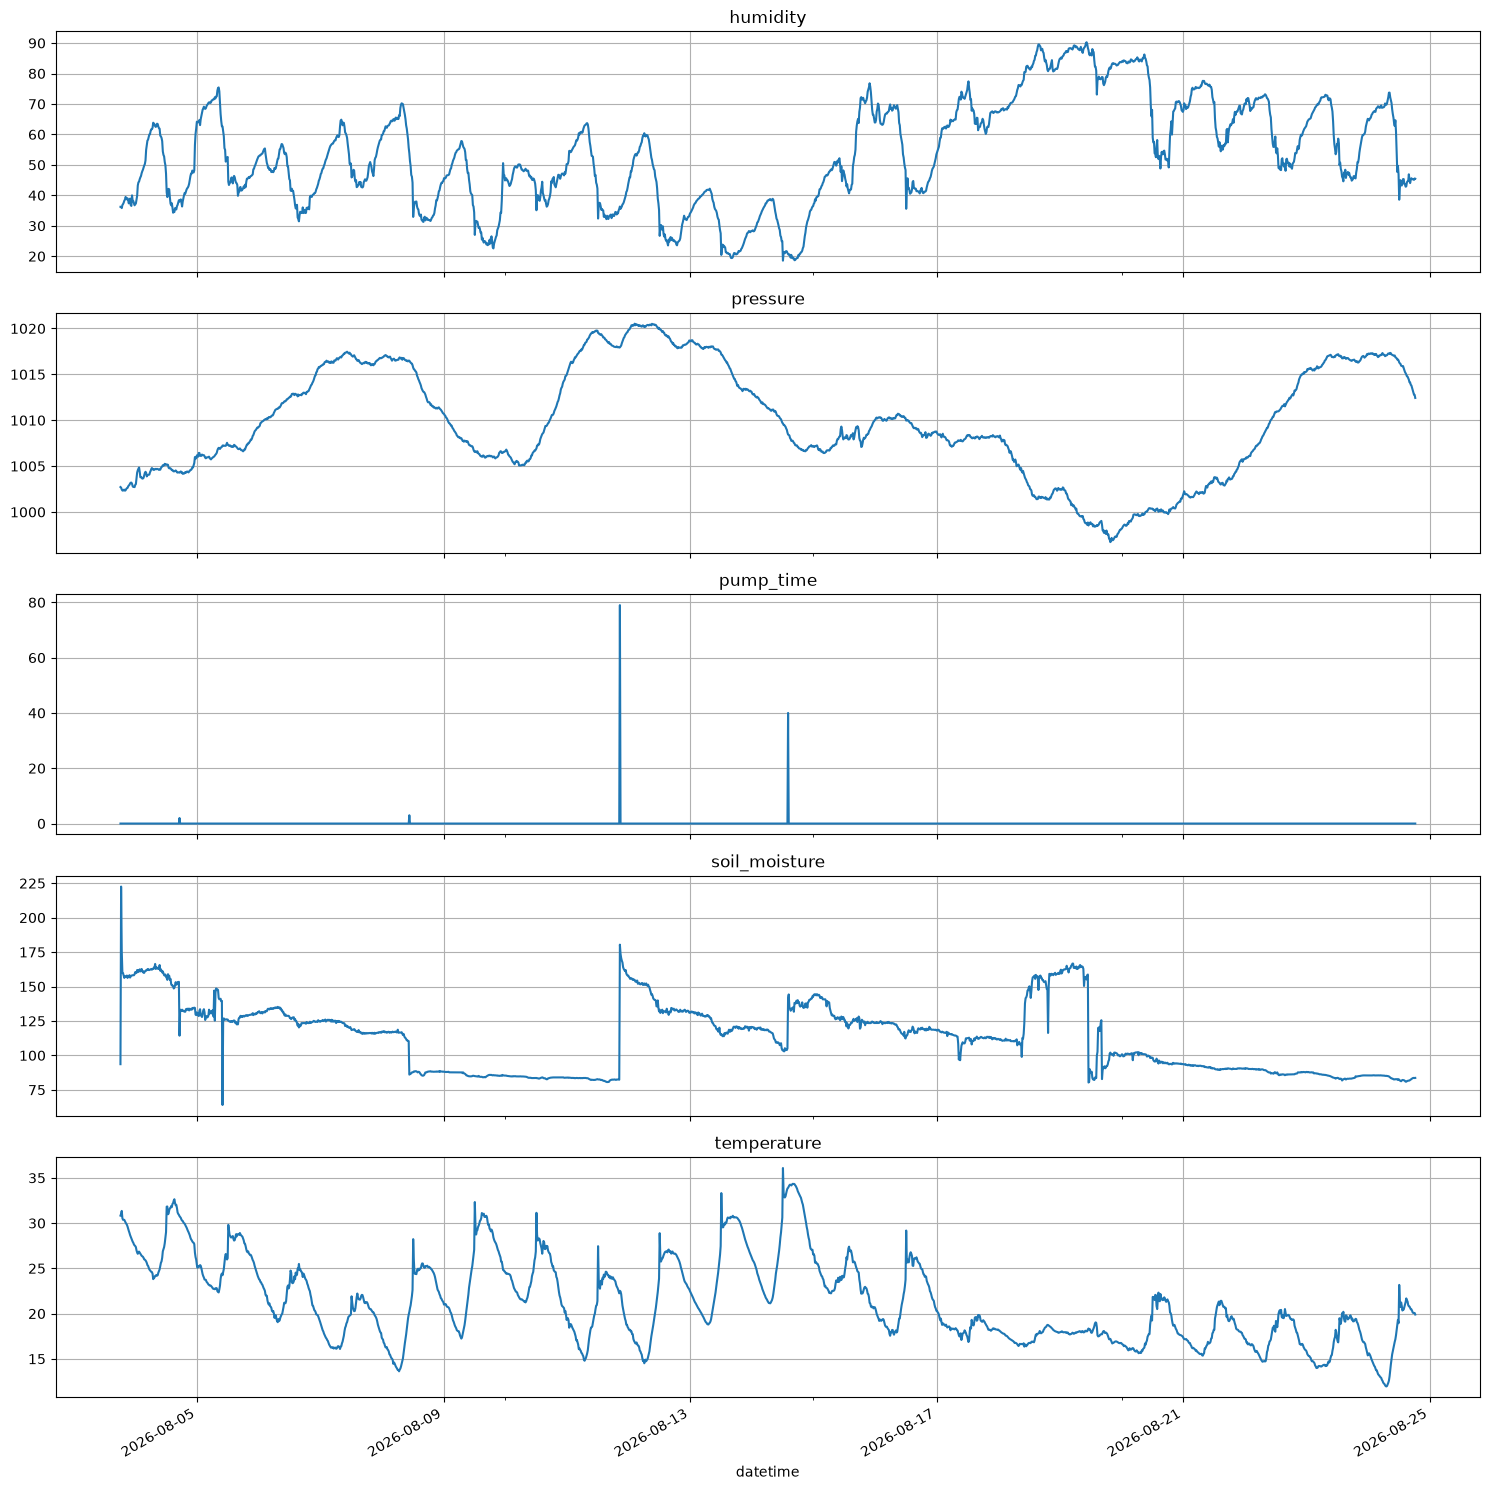

In [8]:
data_aug = data['2026-08-03':]
data_aug = data_aug[~data_aug.duplicated(keep=False)]

plot_cols(data_aug, ignore='timestamp')



### Bereinigung von Sensor-Ausreißern in `soil_moisture`

Wie in den vorherigen Analysen aufgefallen, zeigt `soil_moisture` auch außerhalb von Gießereignissen (`pump_time == 0`) vereinzelt physikalisch unplausible Einzelpunkt-Sprünge (>100 Einheiten in 15 Minuten, die sich in der nächsten Messung sofort wieder zurückbilden). Das sind vermutlich kurze Messfehler des kapazitiven Sensors, keine echten Feuchteänderungen.

Ein **Hampel-Filter** (Median-Filter mit MAD-basierter Ausreißererkennung) erkennt genau diese Art von transienten Einzelpunkt-Ausreißern, ohne echte, anhaltende Feuchteänderungen (z. B. reale Austrocknungstrends oder mögliche manuelle Gießereignisse) zu entfernen – ein Wert wird nur korrigiert, wenn er stark vom lokalen Median abweicht *und* die Nachbarwerte schnell wieder zum ursprünglichen Niveau zurückkehren. Punkte mit `pump_time > 0` werden von der Bereinigung ausgenommen, da dort ein großer Sprung real und erwartet ist.

Erkannte und korrigierte Ausreißer: 61 von 2018 (3.0%)


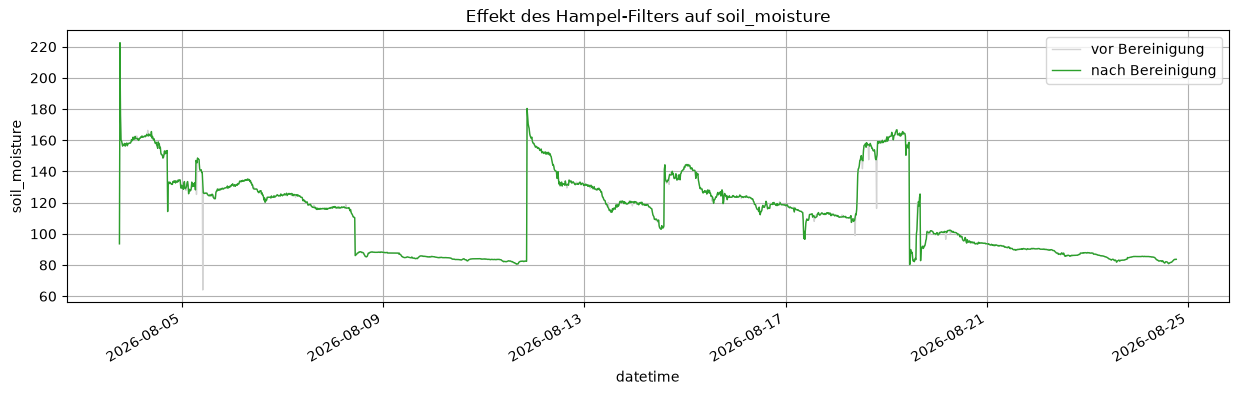

In [9]:
import numpy as np


def hampel_filter(series: pd.Series, protect_mask: pd.Series, window: int = 5, n_sigmas: float = 3) -> pd.Series:
    '''Ersetzt transiente Einzelpunkt-Ausreißer durch lineare Interpolation.
    protect_mask=True schützt Zeilen (z.B. Gießereignisse) vor Korrektur.'''
    rolling_median = series.rolling(window, center=True, min_periods=1).median()
    abs_dev = (series - rolling_median).abs()
    mad = abs_dev.rolling(window, center=True, min_periods=1).median()
    threshold = n_sigmas * 1.4826 * mad  # 1.4826: MAD -> Standardabweichung bei Normalverteilung
    is_outlier = (abs_dev > threshold) & (threshold > 0) & (~protect_mask)

    cleaned = series.copy()
    cleaned[is_outlier] = np.nan
    cleaned = cleaned.interpolate(method='linear').bfill().ffill()
    return cleaned, is_outlier


soil_moisture_raw = data_aug['soil_moisture'].copy()
data_aug['soil_moisture'], outlier_mask = hampel_filter(
    data_aug['soil_moisture'], protect_mask=data_aug['pump_time'] > 0)

print(f'Erkannte und korrigierte Ausreißer: {outlier_mask.sum()} von {len(data_aug)} ({outlier_mask.mean():.1%})')

fig, ax = plt.subplots(figsize=(15, 4))
soil_moisture_raw.plot(ax=ax, label='vor Bereinigung', c='lightgray', lw=1)
data_aug['soil_moisture'].plot(ax=ax, label='nach Bereinigung', c='tab:green', lw=1)
ax.set_ylabel('soil_moisture')
ax.set_title('Effekt des Hampel-Filters auf soil_moisture')
ax.legend()
ax.grid(True)
plt.show()

# Berechnung Sättigungsdefizit (VPD)

In [10]:
from CoolProp.CoolProp import HAPropsSI

# Sättigungsdampf- und Partialdruck für jeden Timestep berechnen
def calc_pressure(df, saturated: bool = False)-> pd.Series:

    if not saturated:
        partial_pressure = df.apply(lambda row:
                                HAPropsSI('P_w',
                                'T', row['temperature'] + 273.15,
                                'P', row['pressure'] * 100,
                                'RH', row['humidity'] / 100), 
                                axis=1)
        return partial_pressure

    else:

        saturated_pressure = df.apply(lambda row:
                                HAPropsSI('P_w',
                                'T', row['temperature'] + 273.15,
                                'P', row['pressure'] * 100,
                                'RH', 1.0),
                                axis=1)
        return saturated_pressure
    

data_aug['partial_pressure'] = calc_pressure(data_aug, saturated=False)
data_aug['saturated_pressure'] = calc_pressure(data_aug, saturated=True)


In [11]:
# Berechnung des Sättigungsdefizits
def calc_VPD(df)-> pd.Series:
    '''VPD in kPa'''
    VPD = (df['saturated_pressure'] - df['partial_pressure']) / 1000
    
    return VPD

data_aug['VPD'] = calc_VPD(data_aug)

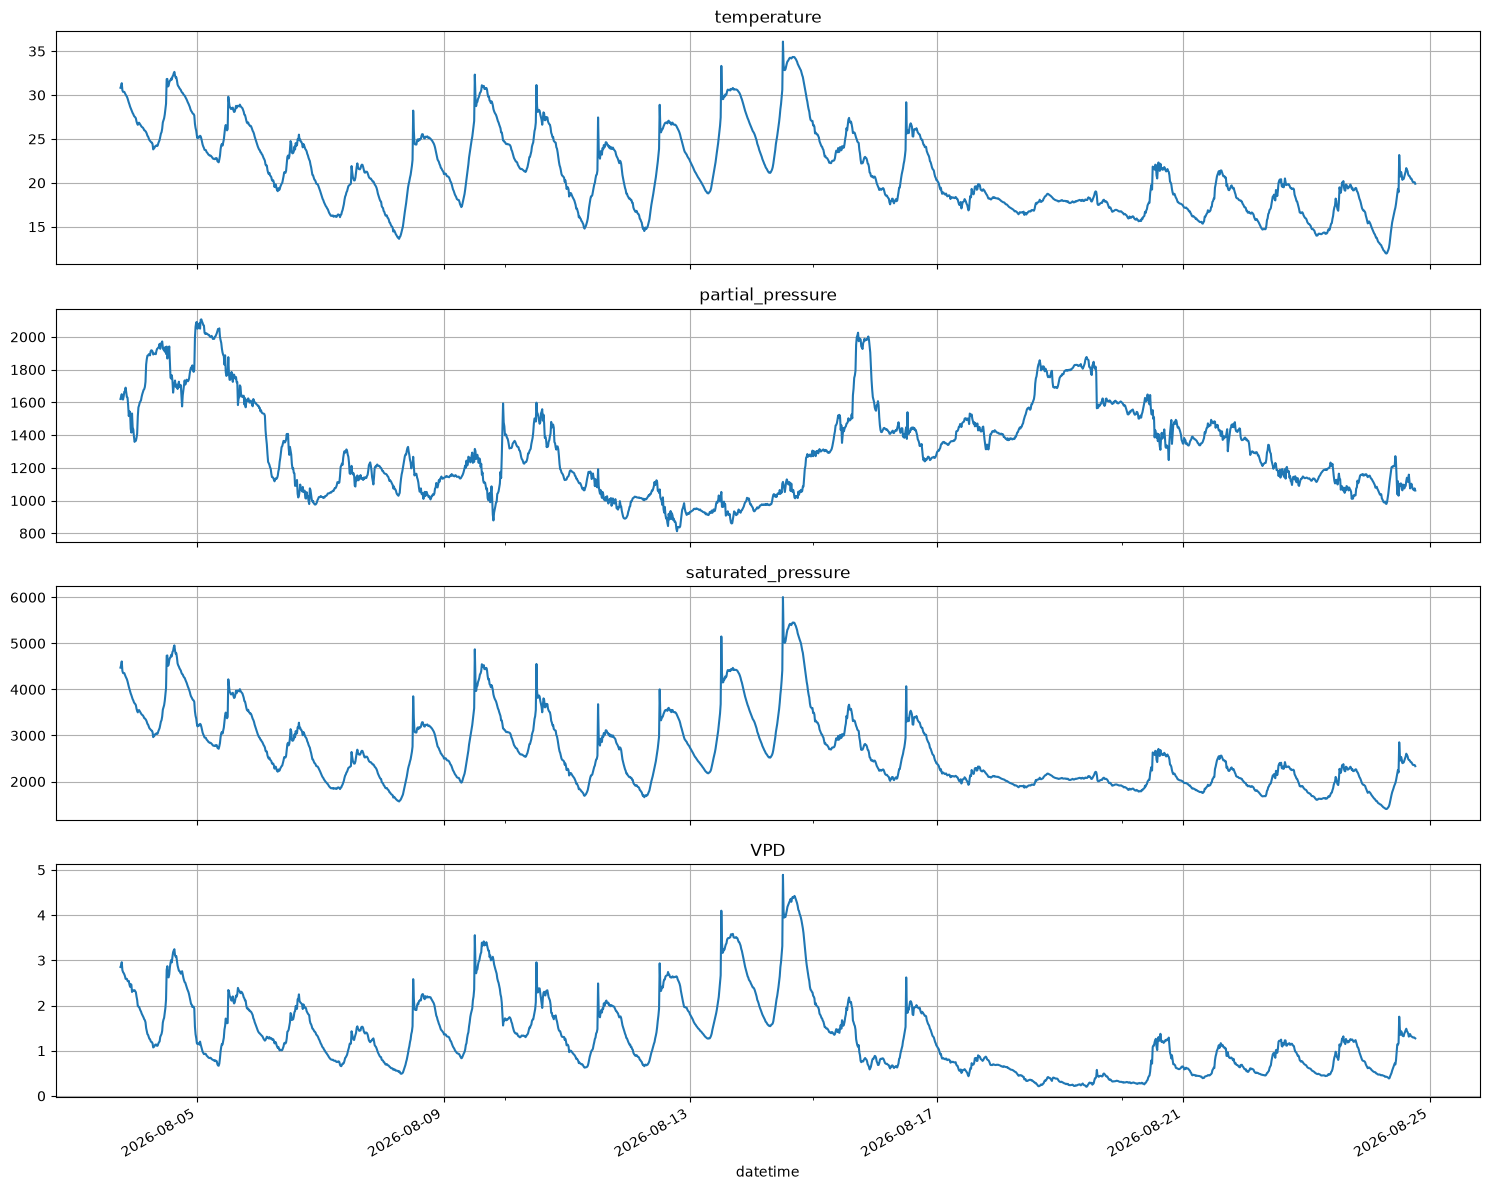

In [12]:
plot_cols(data_aug, ignore=['timestamp', 'humidity', 'pressure', 'pump_time', 'soil_moisture'])

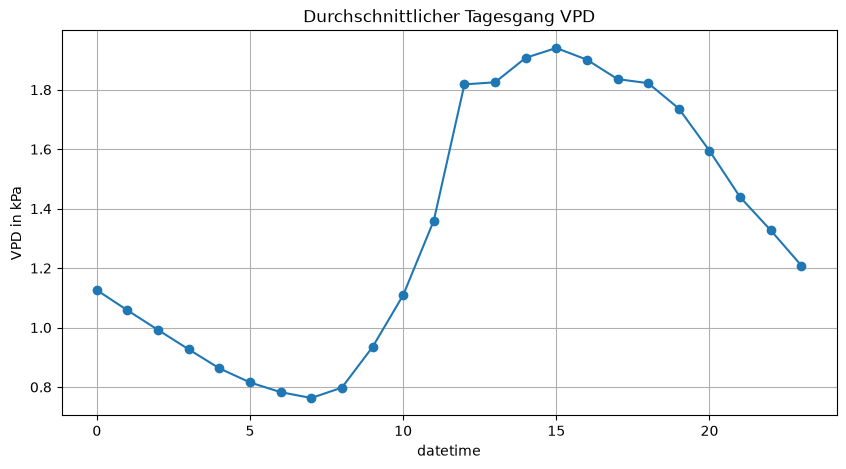

In [13]:
# Durchschnittlicher Tagesverlauf des VPD 
data_aug_vpd = data_aug.groupby(data_aug.index.hour)['VPD'].mean()
ax = data_aug_vpd.plot(figsize=(10,5), title='Durchschnittlicher Tagesgang VPD', marker='o')
ax.set_ylabel('VPD in kPa')
ax.grid(True)

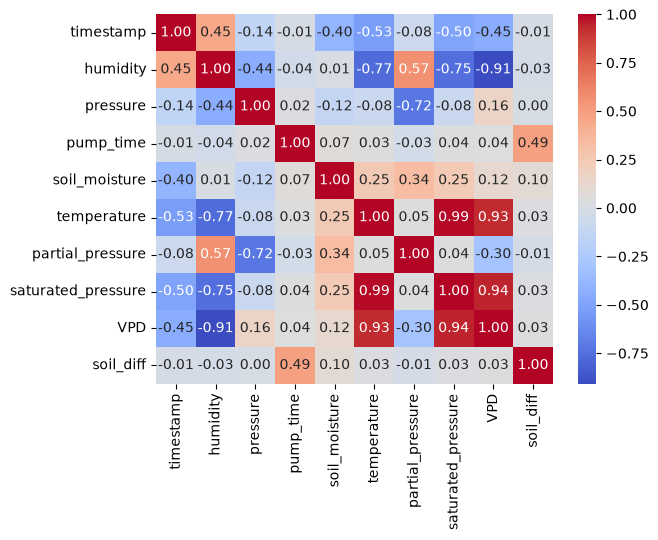

In [14]:
# Austrocknungsrate bestimmen
data_aug['soil_diff'] = data_aug['soil_moisture'].diff()
corr = data_aug.corr(method='pearson')
ax = sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')

# Motivation und Zielstellung
Mit dem beschriebenen Versuchsaufbau soll es später möglich sein die Wasserzufuhr sollwertgeführt zu automatisieren, um ein über- bzw. unterbewässern zu vermeiden und einen guten Ertrag aus dem Beet zu erwirtschaften. Aus einer länger andauernden Messung sollen die aufgenommenen Daten dabei helfen, geeignete Sollwerte zur Bewässerung zu definieren und eventuell Werte aus der Literatur zu validieren. Ein sekundäres Ziel könnte sein die gemessenen Umgebungswerte mit denen eines Wetterdienstes zu vergleichen und zu überprüfen, ob die eigene Messung dieser Werte notwendig ist oder auch die Messungen eines Wetterdienstes mit eventuell leicht abweichendem Standort ausreichend sind. 

geeignete Sollwerte ermitteln

# Machine Learning: Vorhersage der Austrocknungsrate aus VPD

Ziel ist es, den Gießzeitpunkt datenbasiert aus dem VPD vorherzusagen. Im Beobachtungszeitraum (`data_aug`) wurden jedoch nur 4 tatsächliche Pumpenläufe (`pump_time > 0`) aufgezeichnet. Das reicht nicht aus, um den Gießzeitpunkt direkt als Zielgröße zu regressieren – ein Modell auf Basis von 4 Ereignissen wäre reines Overfitting und nicht generalisierbar.

Stattdessen wird die **Austrocknungsrate des Bodens** (`soil_diff`, Änderung der Bodenfeuchte pro 15-Minuten-Intervall) aus dem VPD vorhergesagt. Physikalisch treibt ein hoher VPD die Evapotranspiration und sollte damit die Austrocknungsrate erhöhen. Aus einer vorhergesagten Austrocknungsrate ließe sich der Gießzeitpunkt anschließend ableiten:

$$ t_{Gießen} = \frac{Bodenfeuchte_{aktuell} - Schwelle}{|\text{Austrocknungsrate}|} $$

Zeilen, in denen die Pumpe lief, werden aus dem Trainingsdatensatz entfernt, da `soil_diff` dort den Gießvorgang statt der natürlichen Austrocknung abbildet.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Nur natürliche Austrocknung betrachten (Zeilen ohne Gießereignis)
ml_data = data_aug[data_aug['pump_time'] == 0][['VPD', 'soil_diff']].dropna()

X = ml_data[['VPD']].to_numpy()
y = ml_data['soil_diff'].to_numpy()

# Chronologischer Split (keine zufällige Durchmischung, da Zeitreihe)
split_idx = int(len(ml_data) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f'Trainingsdaten: {len(X_train)}, Testdaten: {len(X_test)}')

Trainingsdaten: 1610, Testdaten: 403


In [16]:
models = {
    'Lineare Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'R2': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
    }

pd.DataFrame(results).T

,R2,MAE
Lineare Regression,-0.07835,0.228293
Random Forest,-1.52756,0.314498


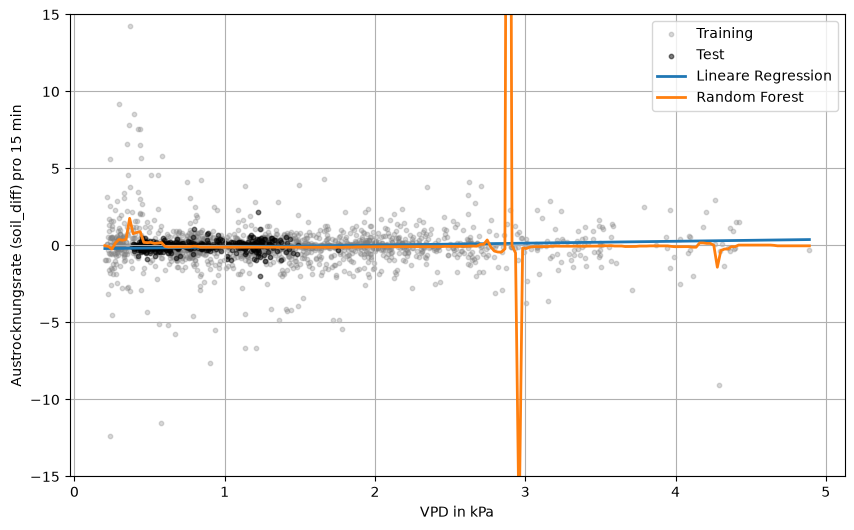

In [17]:
vpd_range = np.linspace(ml_data['VPD'].min(), ml_data['VPD'].max(), 200).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_train, y_train, s=10, alpha=0.3, label='Training', c='gray')
ax.scatter(X_test, y_test, s=10, alpha=0.5, label='Test', c='k')

for name, model in models.items():
    ax.plot(vpd_range, model.predict(vpd_range), label=name, lw=2)

ax.set_xlabel('VPD in kPa')
ax.set_ylabel('Austrocknungsrate (soil_diff) pro 15 min')
ax.set_ylim(-15, 15)  # Ausreißer durch Sensorrauschen ausblenden
ax.legend()
ax.grid(True)
plt.show()

## Ergebnisdiskussion

Beide Modelle erreichen auf den Testdaten ein R² nahe 0 (siehe Tabelle oben) – VPD allein erklärt die Austrocknungsrate in diesem Datensatz kaum. Das gilt unabhängig vom gewählten Modell (linear vs. Random Forest) und wurde auch bei versuchsweiser Glättung über 1–12h-Fenster nicht wesentlich besser (r blieb < 0.11). Es handelt sich also nicht um ein Modellwahl-Problem, sondern um ein Signalproblem. Mögliche Ursachen:

- **Nicht erfasste Wasserzufuhr:** Das Setup steht offenbar im Freien; Niederschlag wird nicht gemessen und könnte die Bodenfeuchte unabhängig vom VPD beeinflussen.
- **Sensorrauschen:** Der kapazitive Feuchtesensor zeigt auch außerhalb von Gießereignissen große Ausreißer (Sprünge > 100 Einheiten in 15 Minuten), die physikalisch nicht plausibel sind.
- **Fehlende Merkmale:** Faktoren wie Windgeschwindigkeit, Sonneneinstrahlung oder der aktuelle Feuchtezustand selbst (Verdunstung hängt auch vom Wassergehalt ab) fehlen im Modell.
- **Kurzer Beobachtungszeitraum:** ca. 3 Wochen mit nur 4 Gießereignissen sind für ein belastbares Modell zu wenig.

Für eine belastbarere Vorhersage würden sich folgende nächste Schritte anbieten: längere Messdauer, zusätzliche Regenmessung (z. B. über die bereits angebundene OpenWeather-API), sowie die Bodenfeuchte selbst als zusätzliches Feature (`soil_moisture` zum Zeitpunkt t-1).

## Realer Sollwertbereich der Steuerung

Die Steuerung (`Aktorik.py`, Klasse `Pumpe.hysterese`) schaltet die Pumpe bei einer Ein- bzw. Ausschalthysterese: Die Pumpe läuft an, sobald `soil_moisture <= 50` (untere Einschaltgrenze der nutzbaren Feldkapazität), und schaltet ab, sobald `soil_moisture >= 80` (obere Ausschaltgrenze). Für Schnittlauch wurde dieser Bereich (50–80) als Sollwertband hinterlegt. Da `min`/`max` dort direkt auf denselben `soil_moisture`-Messwert wirken, der auch in der CSV geloggt wird, lässt sich dieser reale Schwellwert unmittelbar auf die Daten anwenden – anders als ein reiner Prozentwert, da `soil_moisture` (Kalibrierung auf Basis von ml zugegebenem Wasser, s. Abschnitt 1.2.1) nicht auf 0–100 skaliert ist.

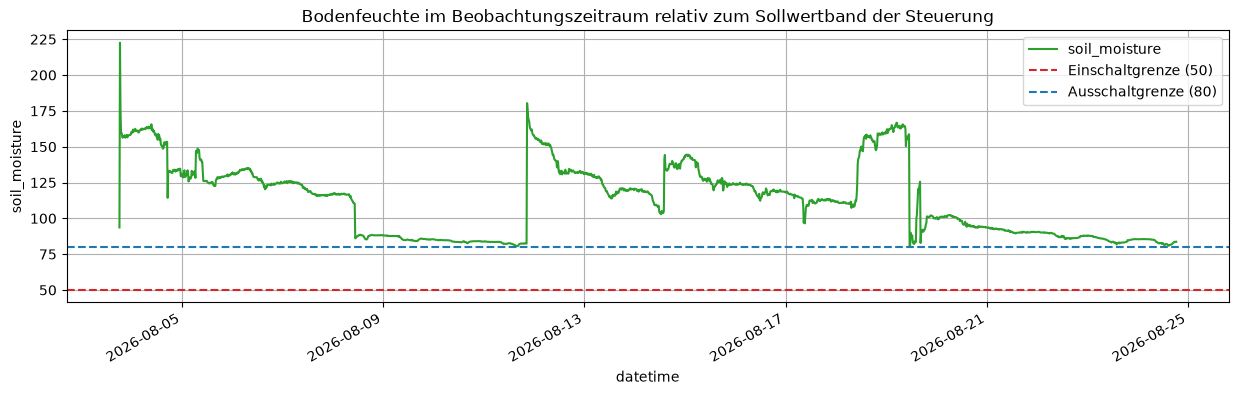

Anteil der Zeit <= 50 (Einschaltgrenze erreicht): 0.0%
Anteil der Zeit <  80 (unterhalb Ausschaltgrenze): 0.0%


In [18]:
PUMP_ON = 50   # untere Einschaltgrenze
PUMP_OFF = 80  # obere Ausschaltgrenze

fig, ax = plt.subplots(figsize=(15, 4))
data_aug['soil_moisture'].plot(ax=ax, label='soil_moisture', c='tab:green')
ax.axhline(PUMP_ON, color='tab:red', ls='--', label=f'Einschaltgrenze ({PUMP_ON})')
ax.axhline(PUMP_OFF, color='tab:blue', ls='--', label=f'Ausschaltgrenze ({PUMP_OFF})')
ax.set_ylabel('soil_moisture')
ax.set_title('Bodenfeuchte im Beobachtungszeitraum relativ zum Sollwertband der Steuerung')
ax.legend()
ax.grid(True)
plt.show()

print(f'Anteil der Zeit <= {PUMP_ON} (Einschaltgrenze erreicht): {(data_aug["soil_moisture"] <= PUMP_ON).mean():.1%}')
print(f'Anteil der Zeit <  {PUMP_OFF} (unterhalb Ausschaltgrenze): {(data_aug["soil_moisture"] < PUMP_OFF).mean():.1%}')

Der Plot zeigt: Im gesamten Beobachtungszeitraum bleibt die Bodenfeuchte praktisch durchgehend **oberhalb** der Ausschaltgrenze von 80 – die Einschaltgrenze (50) wird kein einziges Mal erreicht. Das ist einerseits eine gute Nachricht für die Steuerung (das Beet wurde nie kritisch trocken), bedeutet aber auch, dass sich der reale Schwellwert **nicht** als Klassifikationsziel verwenden lässt: Es gibt in diesem Datensatz schlicht keine "trockenen" Beispiele im agronomischen Sinn, mit denen ein Modell diesen Zustand lernen könnte.

Die folgende Klassifikation verwendet deshalb weiterhin den **Median** als relativen, statistischen Schwellwert ("unterdurchschnittlich feucht" statt "kritisch trocken nach Sollwert"). Um belastbar gegen die realen 50/80-Grenzen zu klassifizieren, wäre eine deutlich längere Messreihe nötig, die auch tatsächlich einmal in den unteren Sollwertbereich fällt (z. B. bei Ausfall der automatischen Bewässerung oder in einer heißeren/trockeneren Periode).

# Klassifikation: Gießbedarf in den nächsten 4 Stunden

Die vorherige Regression zeigte, dass sich die Austrocknungsrate kaum direkt aus dem VPD vorhersagen lässt (R² nahe 0 bzw. negativ). Ergänzende Tests (nicht im Notebook dokumentiert) mit einer reinen Kurzfristprognose der Bodenfeuchte zeigten zudem, dass eine einfache Persistenz-Vorhersage ("Feuchte bleibt wie jetzt") jedem getesteten Regressionsmodell überlegen war.

Deshalb wird das Problem hier als **binäre Klassifikation** formuliert: Wird die Bodenfeuchte in **4 Stunden** (16 Zeitschritte) unter dem **Median** des Beobachtungszeitraums liegen ("unterdurchschnittlich trocken") oder nicht? Als Merkmale werden bewusst **nur Wetterdaten** verwendet – `soil_moisture` selbst wird **nicht** als Feature genutzt. Damit wird gezielt die ursprüngliche Fragestellung getestet: Lässt sich der Gießbedarf allein aus dem VPD/Wetter vorhersagen, unabhängig vom aktuellen Sensorwert?

Da VPD rechnerisch direkt aus Temperatur, Luftfeuchte und Druck abgeleitet ist (s. Abschnitt "Berechnung Sättigungsdefizit"), würde ein Modell mit VPD *und* seinen eigenen Bestandteilen gleichzeitig unter Multikollinearität leiden – die Koeffizienten wären nicht mehr sauber interpretierbar. Deshalb werden mehrere **getrennte** Feature-Sets verglichen, statt sie zu kombinieren:

- **Dummy-Klassifikator** (immer Mehrheitsklasse) → AUC = 0.5 per Definition
- **Nur Tageszeit** (zyklisches Stunden-Feature)
- **VPD + Tageszeit**
- **Rohdaten (Temperatur, Luftfeuchte, Druck) + Tageszeit**

Da Logistic Regression skalenabhängig ist (Temperatur, Luftfeuchte, Druck und VPD liegen auf sehr unterschiedlichen Wertebereichen), werden alle Features vor dem Training mit `StandardScaler` standardisiert – als `Pipeline`, damit der Scaler in jedem Cross-Validation-Fold nur auf den Trainingsdaten angepasst wird (kein Leakage aus dem Testfenster).

Bewertet wird mit **ROC-AUC** über eine zeitreihenbasierte Kreuzvalidierung (`TimeSeriesSplit`, 5 Folds), damit kein zukünftiges Wissen in die Trainingsdaten einfließt.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit

HORIZON = 16  # 16 * 15 min = 4 Stunden

clf_data = data_aug.copy()
clf_data['hour_sin'] = np.sin(2 * np.pi * clf_data.index.hour / 24)
clf_data['hour_cos'] = np.cos(2 * np.pi * clf_data.index.hour / 24)

threshold = clf_data['soil_moisture'].median()
clf_data['future_moisture'] = clf_data['soil_moisture'].shift(-HORIZON)
clf_data['target'] = (clf_data['future_moisture'] < threshold).astype(int)

hour_features = ['hour_sin', 'hour_cos']
vpd_features = ['VPD', 'hour_sin', 'hour_cos']
raw_features = ['temperature', 'humidity', 'pressure', 'hour_sin', 'hour_cos']

clf_data = clf_data.dropna(subset=['future_moisture'] + raw_features + vpd_features)

print(f'Schwellwert (Median soil_moisture): {threshold:.1f}')
print(f'Anteil positiver Klasse (wird trocken): {clf_data["target"].mean():.2f}')
print(f'Anzahl Beobachtungen: {len(clf_data)}')

Schwellwert (Median soil_moisture): 115.8
Anteil positiver Klasse (wird trocken): 0.50
Anzahl Beobachtungen: 2002


In [20]:
tscv = TimeSeriesSplit(n_splits=5, test_size=200)

auc_scores = {
    'Dummy (Mehrheitsklasse)': [],
    'Nur Tageszeit': [],
    'VPD + Tageszeit': [],
    'Rohdaten (Temp/Feuchte/Druck) + Tageszeit': [],
    'Random Forest (Rohdaten)': [],
}

for train_idx, test_idx in tscv.split(clf_data):
    train, test = clf_data.iloc[train_idx], clf_data.iloc[test_idx]
    y_train, y_test = train['target'], test['target']

    # Fold überspringen, falls Test- oder Trainingsfenster nur eine Klasse enthält (AUC dann nicht definiert)
    if y_train.nunique() < 2 or y_test.nunique() < 2:
        continue

    auc_scores['Dummy (Mehrheitsklasse)'].append(0.5)

    for label, feats in [('Nur Tageszeit', hour_features),
                          ('VPD + Tageszeit', vpd_features),
                          ('Rohdaten (Temp/Feuchte/Druck) + Tageszeit', raw_features)]:
        pipe = make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced', max_iter=1000))
        pipe.fit(train[feats], y_train)
        auc_scores[label].append(roc_auc_score(y_test, pipe.predict_proba(test[feats])[:, 1]))

    rf = RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=10,
                                 class_weight='balanced', random_state=42)
    rf.fit(train[raw_features], y_train)
    auc_scores['Random Forest (Rohdaten)'].append(
        roc_auc_score(y_test, rf.predict_proba(test[raw_features])[:, 1]))

auc_summary = pd.DataFrame(auc_scores)
auc_summary.loc['Mittelwert'] = auc_summary.mean()
auc_summary

,Dummy (Mehrheitsklasse),Nur Tageszeit,VPD + Tageszeit,Rohdaten (Temp/Feuchte/Druck) + Tageszeit,Random Forest (Rohdaten)
0,0.5,0.780275,0.710145,0.942766,0.784328
1,0.5,0.490832,0.582354,0.609104,0.119405
2,0.5,0.565564,0.486817,0.813634,0.341303
Mittelwert,0.5,0.612224,0.593105,0.788501,0.415012


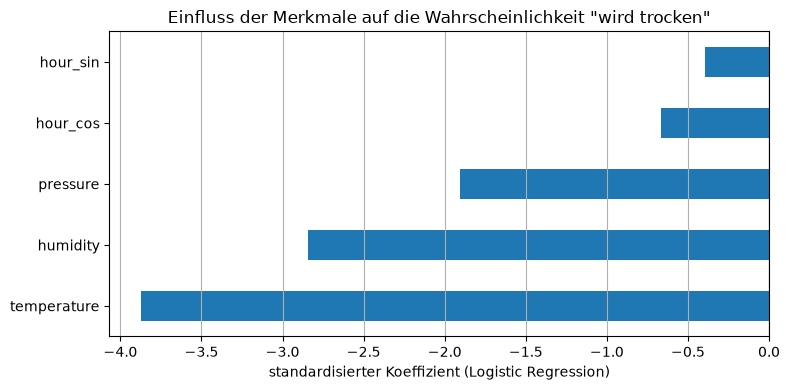

In [21]:
# Finales Modell auf dem gesamten Datensatz für die Interpretation (Rohdaten-Feature-Set)
final_pipe = make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced', max_iter=1000))
final_pipe.fit(clf_data[raw_features], clf_data['target'])

coef = pd.Series(final_pipe.named_steps['logisticregression'].coef_[0], index=raw_features).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
coef.plot(kind='barh', ax=ax, color=['tab:red' if v > 0 else 'tab:blue' for v in coef])
ax.set_xlabel('standardisierter Koeffizient (Logistic Regression)')
ax.set_title('Einfluss der Merkmale auf die Wahrscheinlichkeit "wird trocken"')
ax.axvline(0, color='k', lw=0.8)
ax.grid(True, axis='x')
plt.tight_layout()
plt.show()

## Ergebnisdiskussion

Im Gegensatz zur Regression liefert die Klassifikation ein brauchbares Ergebnis – allerdings mit einer Überraschung:

| Modell | mittlere ROC-AUC |
| :--- | :--- |
| Dummy (Mehrheitsklasse) | 0.50 |
| Nur Tageszeit | 0.61 |
| VPD + Tageszeit | 0.59 |
| **Rohdaten (Temp/Feuchte/Druck) + Tageszeit** | **0.79** |
| Random Forest (Rohdaten) | 0.42 |

**VPD allein schneidet nicht besser ab als die reine Tageszeit-Baseline (0.59 vs. 0.61)** – die physikalisch motivierte, kompakte Kennzahl VPD verliert hier gegenüber den drei Rohgrößen, aus denen sie berechnet wird, an Vorhersagekraft. Erst Temperatur, Luftfeuchte und Druck **zusammen** als eigenständige Features erreichen AUC 0.79. Eine mögliche Erklärung: VPD ist eine physikalisch sinnvolle, aber nichtlineare und verlustbehaftete Kombination dieser drei Größen; ein lineares Modell wie Logistic Regression kann aus den Rohgrößen selbst flexiblere (auch andere) Linearkombinationen lernen, als ihm die vorgefertigte VPD-Formel vorgibt. Die ursprüngliche Fragestellung ("sagt VPD den Gießbedarf vorher?") lässt sich damit eher verneinen – es ist die Kombination der Wetterrohdaten, nicht VPD im Speziellen, die hier trägt.

Die einzelnen Koeffizienten des Rohdaten-Modells (Plot oben) sollten trotz Standardisierung mit Vorsicht interpretiert werden: Temperatur, Luftfeuchte und Druck sind im Tagesverlauf selbst korreliert, sodass auch hier eine gewisse Multikollinearität bestehen bleibt – die Vorzeichen einzelner Koeffizienten sind daher nicht ohne Weiteres kausal zu lesen, auch wenn das Gesamtmodell gut vorhersagt.

Wie schon in der Regression schneidet der **Random Forest schlechter als der Dummy-Klassifikator** ab (AUC 0.42). Bei nur ca. 2000 Datenpunkten aus 3 Wochen neigt das flexiblere Modell zum Overfitting auf Rauschen und trainings-spezifische Muster, die sich nicht auf neue Zeiträume übertragen lassen.

**Einschränkungen:** Der Schwellwert (Median) ist statistisch, nicht agronomisch definiert (s. Abschnitt "Realer Sollwertbereich der Steuerung" – die echten 50/80-Grenzen wurden im Beobachtungszeitraum nie erreicht). Zudem wurde absichtlich auf `soil_moisture` als Feature verzichtet; ein reales Bewässerungssystem hätte natürlich Zugriff auf den aktuellen Sensorwert. Für die Praxis ließe sich das Rohdaten-Modell trotzdem sinnvoll einsetzen: als Frühwarnindikator, der allein aus einer Wettervorhersage (z. B. über die OpenWeather-API) abschätzt, ob in den nächsten Stunden erhöhter Gießbedarf zu erwarten ist.